In [1]:
import pymc as pm, polars as pl, arviz as az

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [5]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/Hurricanes.csv", separator=";")

df = standardize_columns(df, columns=["femininity"])

In [9]:
with pm.Model() as model:
    femininity = pm.Data("femininity", df["femininity"].to_numpy())

    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1)

    expected_count = pm.Deterministic("expected_count", pm.math.exp(alpha + beta*femininity))

    deaths = pm.Poisson("deaths", expected_count, observed = df["deaths"].to_numpy())

    # sample priors
    basic_prior_predictive = pm.sample_prior_predictive(var_names=["deaths", "expected_count"])

    # sample å
    posterior = pm.sample(chains=4)
    posterior_predictive = pm.sample_posterior_predictive(posterior, var_names=["deaths", "expected_count"])
    pm.compute_log_likelihood(posterior)

Sampling: [alpha, beta, deaths]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [deaths]


Output()

Output()

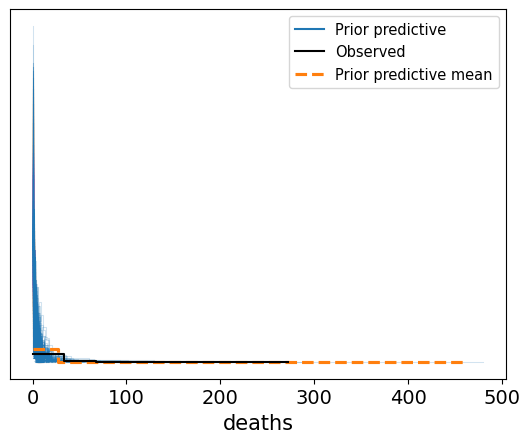

In [10]:
# prior predictive check
ax = az.plot_ppc(basic_prior_predictive, group="prior", observed=True)

array([[<Axes: title={'center': 'x'}>]], dtype=object)

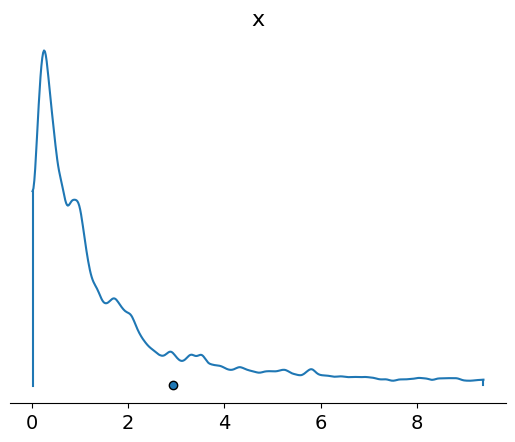

In [13]:
az.plot_density(basic_prior_predictive.prior["expected_count"].values.flatten())

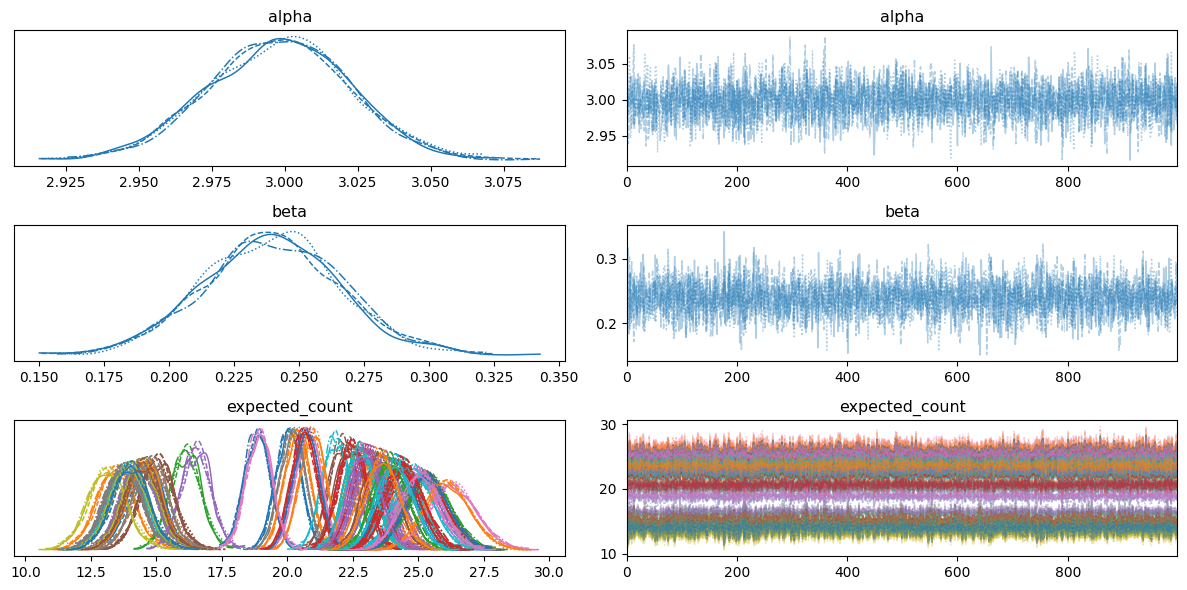

In [11]:
plot_trace(posterior)

In [14]:
with pm.Model() as basic_model:
    femininity = pm.Data("femininity", df["femininity"].to_numpy())

    alpha = pm.Normal("alpha", mu=0, sigma=1)

    expected_count = pm.Deterministic("expected_count", pm.math.exp(alpha))

    deaths = pm.Poisson("deaths", expected_count, observed = df["deaths"].to_numpy())

    # sample priors
    basic_prior_predictive = pm.sample_prior_predictive(var_names=["deaths", "expected_count"])

    # sample å
    basic_posterior = pm.sample(chains=4)
    basic_posterior_predictive = pm.sample_posterior_predictive(basic_posterior, var_names=["deaths", "expected_count"])
    pm.compute_log_likelihood(basic_posterior)

Sampling: [alpha, deaths]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [deaths]


Output()

Output()

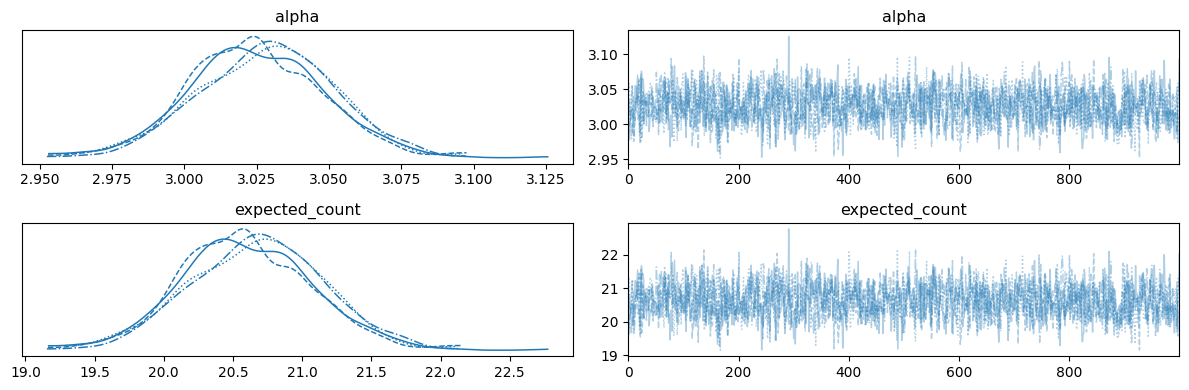

In [15]:
plot_trace(basic_posterior)

In [21]:
comparison = az.compare({
    "femininity": posterior,
    "basic": basic_posterior
}, scale="deviance", ic="waic")
comparison

/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
femininity,0,4425.581479,138.942396,0.000000,0.470396,1006.171520,0.000000,True,deviance
basic,1,4435.090920,80.920224,9.509441,0.529604,1067.917128,133.770148,True,deviance


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_waic (deviance)', ylabel='ranked models'>

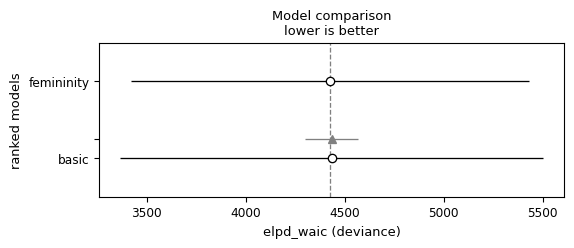

In [22]:
az.plot_compare(comparison, plot_ic_diff=True)

In [23]:
posterior

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
	> constant_data

In [25]:
posterior.log_likelihood["deaths"].shape

(4, 1000, 92)

In [31]:
loo_result = az.loo(posterior, pointwise=True)
waic_result = az.waic(posterior, pointwise=True)

# Add to dataframe
df = df.with_columns([
    pl.Series("elpd_loo", loo_result.loo_i.values),
    pl.Series("pareto_k", loo_result.pareto_k.values),
    pl.Series("elpd_waic", waic_result.waic_i.values)
])

df = extract_quantile_columns(df, posterior_predictive.posterior_predictive, outcome_name="deaths", quantiles=[0.1, 0.5, 0.9])

/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [33]:
df.drop("year", "category", "min_pressure", "damage_norm", "female")

name,deaths,femininity,elpd_loo,pareto_k,elpd_waic,_deaths_10.0,_deaths_50.0,_deaths_90.0
str,i64,f64,f64,f64,f64,f64,f64,f64
"""Easy""",2,-0.000935,-14.840519,0.083671,-14.84011,14.0,20.0,26.0
"""King""",4,-1.670758,-6.379177,0.10966,-6.377801,9.0,13.0,18.0
"""Able""",3,-0.913314,-9.69638,0.155459,-9.695194,11.0,16.0,21.0
"""Barbara""",1,0.94587,-22.205241,0.196799,-22.204675,19.0,25.0,32.0
"""Florence""",0,0.481074,-22.655046,0.121132,-22.655395,17.0,22.0,29.0
…,…,…,…,…,…,…,…,…
"""Gustav""",52,-1.567471,-35.860903,0.553785,-35.828042,9.0,14.0,19.0
"""Ike""",84,-1.515826,-90.30647,1.172931,-90.827457,9.0,14.0,19.0
"""Irene""",41,0.773725,-7.767697,0.111744,-7.767249,18.0,24.0,30.0
